# Ejercicio de programación Regresión Lineal Multiple

In [1]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np

# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [2]:
from google.colab import drive
drive.mount("/content/gdrive")

Mounted at /content/gdrive


## 2 Regresión lineal con multiples variables



<a id="section4"></a>
### 2.1 Normalización de caracteristicas



In [3]:
with open('/content/gdrive/MyDrive/IA 1/datasets/capstone_smartgrid_20000.csv', 'r') as f:
    header = f.readline()
print(header)

meter_id,timestamp,region,building_type,floor_area_m2,insulation_rating,hvac_age_years,solar_kw_installed,ev_charger,hour,day_of_week,is_weekend,is_holiday,tariff_tier,temp_c,humidity_pct,wind_ms,precip_mm,grid_price_usd_per_kwh,occupancy_index,solar_generation_kwh,consumption_kwh,next_hour_consumption_kwh,lag1_kwh,lag24_kwh,roll24_mean_kwh,roll24_std_kwh,high_usage_flag,anomaly_flag,sensor_health,outage_risk_score



In [4]:
data = np.loadtxt(
    '/content/gdrive/MyDrive/IA 1/datasets/capstone_smartgrid_20000.csv',
    delimiter=',',
    skiprows=1,
    usecols=(4, 6, 21)  # floor_area_m2, hvac_age_years, consumption_kwh
)
X = data[:, :2]
y = data[:, 2]
m = y.size
print(m)
print('{:>8s}{:>8s}{:>10s}'.format('X[:,0]', 'X[:, 1]', 'y'))
print('-'*26)
for i in range(10):
    print('{:8.0f}{:8.0f}{:10.0f}'.format(X[i, 0], X[i, 1], y[i]))

20000
  X[:,0] X[:, 1]         y
--------------------------
     113      16         3
     113      16         3
     113      16         3
     113      16         2
     113      16         3
     113      16         2
     113      16         2
     113      16         2
     113      16         1
     113      16         0


In [5]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [6]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[113.          16.48692357]
 [113.          16.48692357]
 [113.          16.48692357]
 ...
 [105.           9.13996645]
 [105.           9.13996645]
 [105.           9.13996645]]
Media calculada: [175.1          8.39235158]
Desviación estandar calculada: [66.8964872   4.29981113]
[[-0.92829986  1.88254129]
 [-0.92829986  1.88254129]
 [-0.92829986  1.88254129]
 ...
 [-1.04788761  0.17387156]
 [-1.04788761  0.17387156]
 [-1.04788761  0.17387156]]


Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

In [7]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [8]:
print(X)

[[ 1.         -0.92829986  1.88254129]
 [ 1.         -0.92829986  1.88254129]
 [ 1.         -0.92829986  1.88254129]
 ...
 [ 1.         -1.04788761  0.17387156]
 [ 1.         -1.04788761  0.17387156]
 [ 1.         -1.04788761  0.17387156]]


<a id="section5"></a>
### 2.2 Descenso por el gradiente

En el ejemplo anterior se implemento el descenso por el gradiente para un problema de regresion univariable. La unica diferencia es que ahora existe una caracteristica adicional en la matriz $X$. La función de hipótesis y la regla de actualización del descenso del gradiente por lotes permanecen sin cambios.

La implementacion de las funciones `computeCostMulti` y `gradientDescentMulti` son similares a la funcion de costo y función de descenso por el gradiente de la regresión lineal multiple es similar al de la regresion lineal multivariable. Es importante garantizar que el codigo soporte cualquier numero de caracteristicas y esten bien vectorizadas.

Se puede utilizar `shape`, propiedad de los arrays `numpy`, para identificar cuantas caracteristicas estan consideradas en el dataset.

<div class="alert alert-block alert-warning">
**Nota de implementación:** En el caso de multivariables, la función de costo puede se escrita considerando la forma vectorizada de la siguiente manera:

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

donde:

$$ X = \begin{pmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T - \\ \\
\end{pmatrix} \qquad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \\\end{bmatrix}$$

La version vectorizada es eficiente cuando se trabaja con herramientas de calculo numericos computacional como `numpy`.
</div>

<a id="computeCostMulti"></a>

In [9]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [10]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


theta calculado por el descenso por el gradiente: [ 1.55656285  0.54487843 -0.01615276]
El consumo horario predecido para un medidor con area de 120 m2 y HVAC de 5 años (usando el descenso por el gradiente): 1.12 kWh


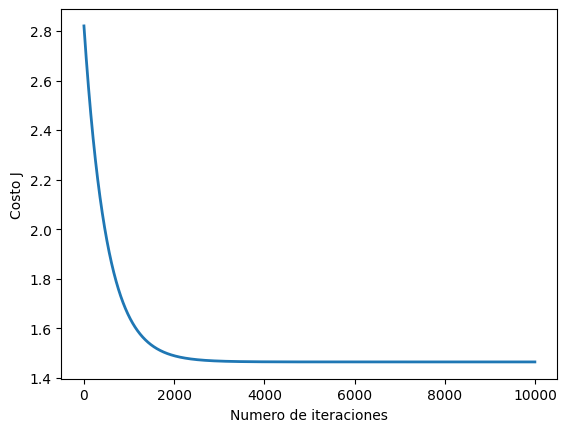

In [11]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.001 # alpha = 0.003
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(3)
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# Estimar el consumo horario para un medidor inteligente con area de 120 m2
# y un sistema HVAC de 5 años de antiguedad
X_array = [1, 120, 5]
X_array[1:3] = (X_array[1:3] - mu) / sigma
consumo = np.dot(X_array, theta)

print('El consumo horario predecido para un medidor con area de 120 m2 y HVAC de 5 años (usando el descenso por el gradiente): {:.2f} kWh'.format(consumo))

In [12]:
X_array = [1, 120, 5]
# X_array[1:3] = (X_array[1:3] - mu) / sigma

In [13]:
price = np.dot(X_array, theta)   # Se debe cambiar esto

print('El consumo horario predecido para un medidor con area de 100 m2 y HVAC de 8 años (usando la ecuacion normal): {:.2f} kWh'.format(consumo))

El consumo horario predecido para un medidor con area de 100 m2 y HVAC de 8 años (usando la ecuacion normal): 1.12 kWh


<a id="section7"></a>
### 2.3 Ecuacion de la Normal

Una manera de calcular rapidamente el modelo de una regresion lineal es:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizando esta formula no requiere que se escale ninguna caracteristica, y se obtendra una solucion exacta con un solo calculo: no hay “bucles de convergencia” como en el descenso por el gradiente.

Primero se recargan los datos para garantizar que las variables no esten modificadas. Recordar que no es necesario escalar las caracteristicas, se debe agregar la columna de unos a la matriz $X$ para tener el termino de intersección($\theta_0$).

In [14]:
# Cargar datos
data = np.loadtxt(
    '/content/gdrive/MyDrive/IA 1/datasets/capstone_smartgrid_20000.csv',
    delimiter=',',
    skiprows=1,
    usecols=(4, 6, 21)  # floor_area_m2, hvac_age_years, consumption_kwh
)
X = data[:, :2]
y = data[:, 2]
m = y.size
print(m)
X = np.concatenate([np.ones((m, 1)), X], axis=1)

20000


In [15]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    theta = np.dot(np.dot(np.linalg.inv(np.dot(X.T,X)),X.T),y)

    return theta

In [16]:
# Calcula los parametros con la ecuación de la normal
theta = normalEqn(X, y);

# Muestra los resultados optenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal: {:s}'.format(str(theta)));

# Estimar el precio para una casa de superficie de 1650 sq-ft y tres dormitorios

X_array = [1, 500, 5]
price = np.dot(X_array, theta)

print('Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): ${:.0f}'.format(price))

Theta calculado a partir de la ecuación de la normal: [ 0.16191046  0.00814567 -0.00376349]
Precio predecido para una cada de superficie de 1650 sq-ft y 3 dormitorios (usando la ecuación de la normal): $4
